In [1]:
from IPython.display import HTML
HTML("""
<style>
div.input {display:none;}
div.output_area {max-width: 100%;}
h1, h2, h3 {font-family: Arial, sans-serif;}
</style>
""")

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = "quantum_jobs.db"

In [3]:
def run_query(sql: str) -> pd.DataFrame:
    conn = sqlite3.connect(str(DB_PATH))
    df = pd.read_sql_query(sql, conn)
    conn.close()
    return df

In [4]:
df_current = run_query("""
SELECT title, department, location, modality
FROM job_current
WHERE company = 'Quantum Machines'
ORDER BY department, location;
""")

df_current

,title,department,location,modality
0,Hardware Prototyping Engineer,Architecture,Tel Aviv Israel,Hybrid
1,Senior System Architect,Architecture,Tel Aviv Israel,On-site
2,Software Architect,Architecture,Tel Aviv Israel,On-site
3,Office & Logistics Assistant,COO,Stuttgart Germany,On-site
4,Quality Engineer,COO,Tel Aviv Israel,On-site
...,...,...,...,...
68,Scientific Business Development Manager,Sales,Korea Remote,Remote
69,Scientific Business Development Manager,Sales,Singapore Remote,Remote
70,Scientific Business Development Manager,Sales,Stuttgart Germany,Hybrid
71,Scientific Business Development Manager,Sales,USA-Remote,Remote


In [5]:
df_dept = run_query("""
SELECT department, COUNT(*) as n
FROM job_current
WHERE company = 'Quantum Machines'
GROUP BY department
ORDER BY n DESC;
""")

df_dept

,department,n
0,R&D,31
1,Customer Success,15
2,Product,9
3,Sales,6
4,Marketing,4
5,Architecture,3
6,COO,2
7,IT - Information Systems,1
8,IQCC,1
9,Finance,1


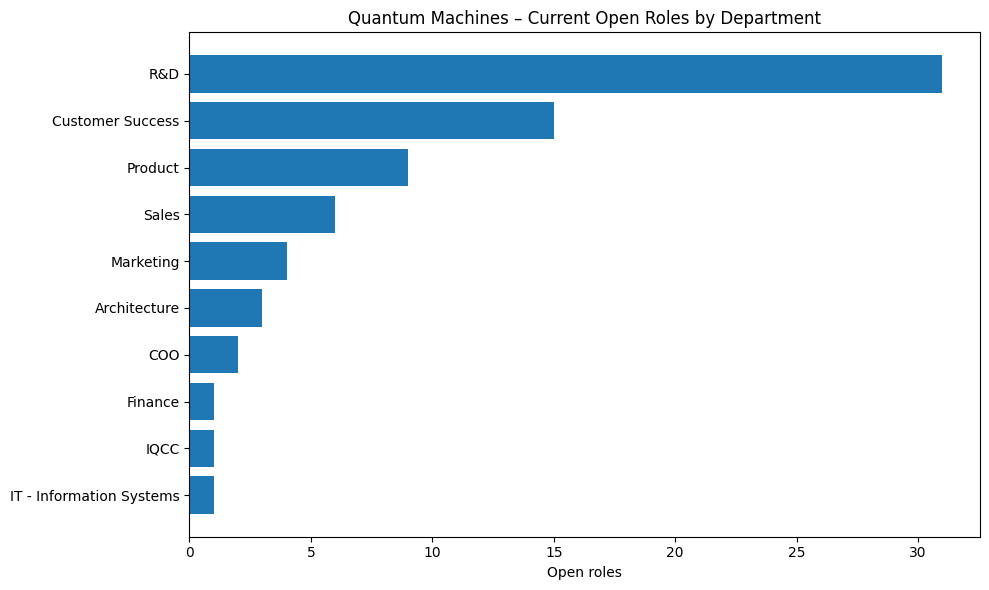

In [6]:
df_dept = run_query("""
SELECT COALESCE(department, '(Unknown)') AS department, COUNT(*) AS n
FROM job_current
WHERE company = 'Quantum Machines'
GROUP BY department
ORDER BY n DESC;
""")

df_dept_sorted = df_dept.sort_values("n")

plt.figure(figsize=(10, 6))
plt.barh(df_dept_sorted["department"], df_dept_sorted["n"])
plt.title("Quantum Machines – Current Open Roles by Department")
plt.xlabel("Open roles")
plt.tight_layout()
plt.show()

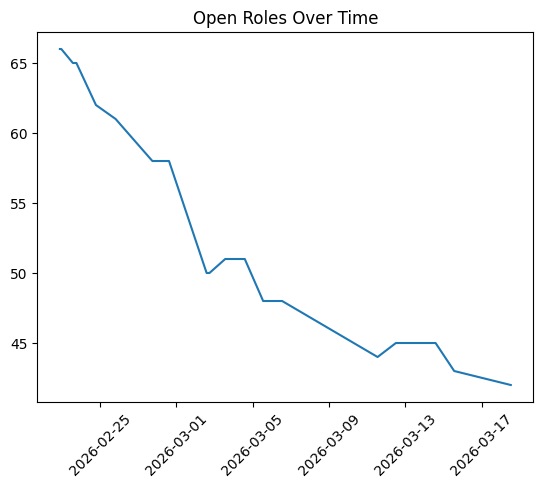

In [7]:
df_time = run_query("""
SELECT pulled_at, COUNT(*) as open_roles
FROM job_snapshots
WHERE company = 'Quantum Machines'
GROUP BY pulled_at
ORDER BY pulled_at;
""")

df_time["pulled_at"] = pd.to_datetime(df_time["pulled_at"])

plt.figure()
plt.plot(df_time["pulled_at"], df_time["open_roles"])
plt.xticks(rotation=45)
plt.title("Open Roles Over Time")
plt.show()

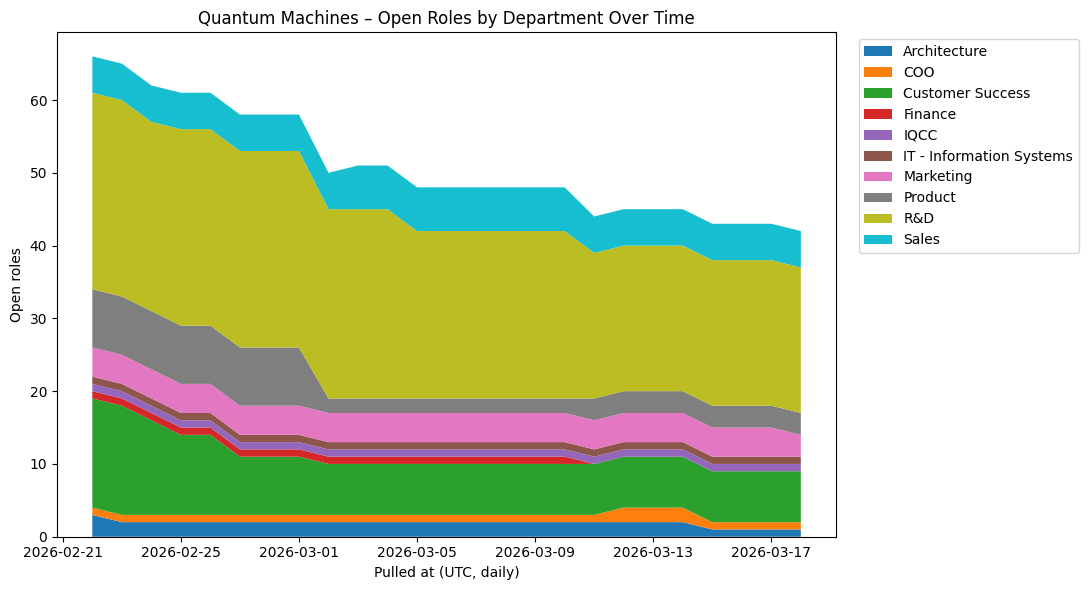

In [8]:
df_dept_time = run_query("""
SELECT pulled_at, department, COUNT(*) AS n
FROM job_snapshots
WHERE company = 'Quantum Machines'
GROUP BY pulled_at, department
ORDER BY pulled_at, department;
""")

df_dept_time["pulled_at"] = pd.to_datetime(df_dept_time["pulled_at"], utc=True)

# Pivot to: rows=time, columns=department, values=count
pivot = (df_dept_time
         .pivot_table(index="pulled_at", columns="department", values="n", fill_value=0)
         .sort_index())

# Optional: resample to daily so the x-axis is cleaner once you have many intraday pulls
pivot_daily = pivot.resample("D").last().ffill()

plt.figure(figsize=(11, 6))
plt.stackplot(pivot_daily.index, pivot_daily.T.values, labels=pivot_daily.columns)
plt.title("Quantum Machines – Open Roles by Department Over Time")
plt.xlabel("Pulled at (UTC, daily)")
plt.ylabel("Open roles")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

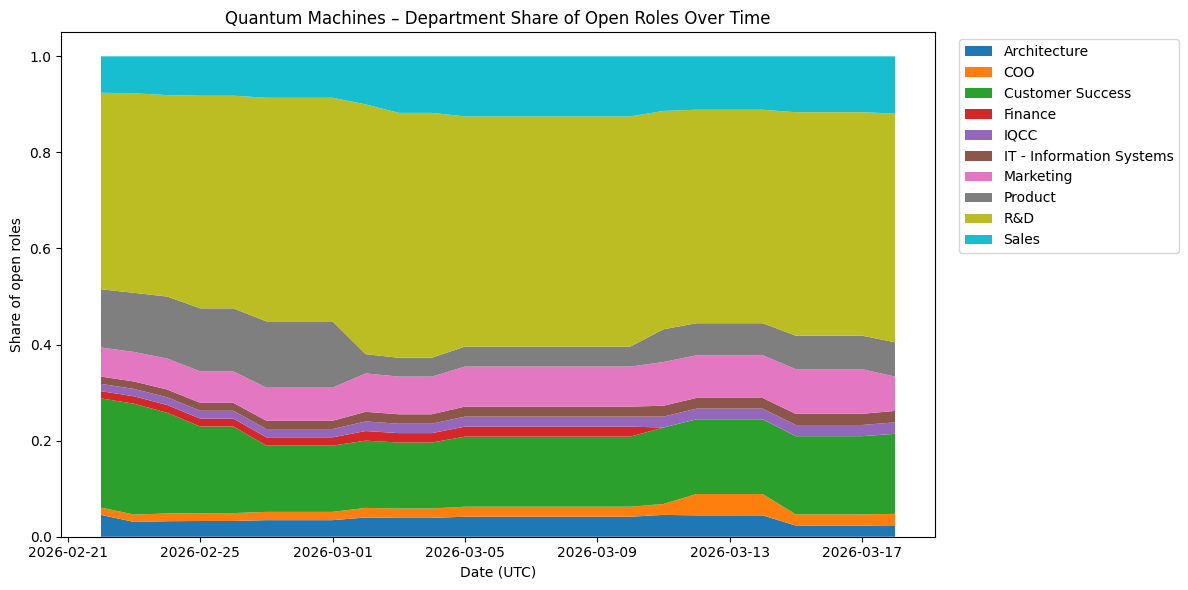

In [9]:
share_daily = pivot_daily.div(pivot_daily.sum(axis=1), axis=0).fillna(0)

plt.figure(figsize=(12, 6))
plt.stackplot(share_daily.index, share_daily.T.values, labels=share_daily.columns)
plt.title("Quantum Machines – Department Share of Open Roles Over Time")
plt.xlabel("Date (UTC)")
plt.ylabel("Share of open roles")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

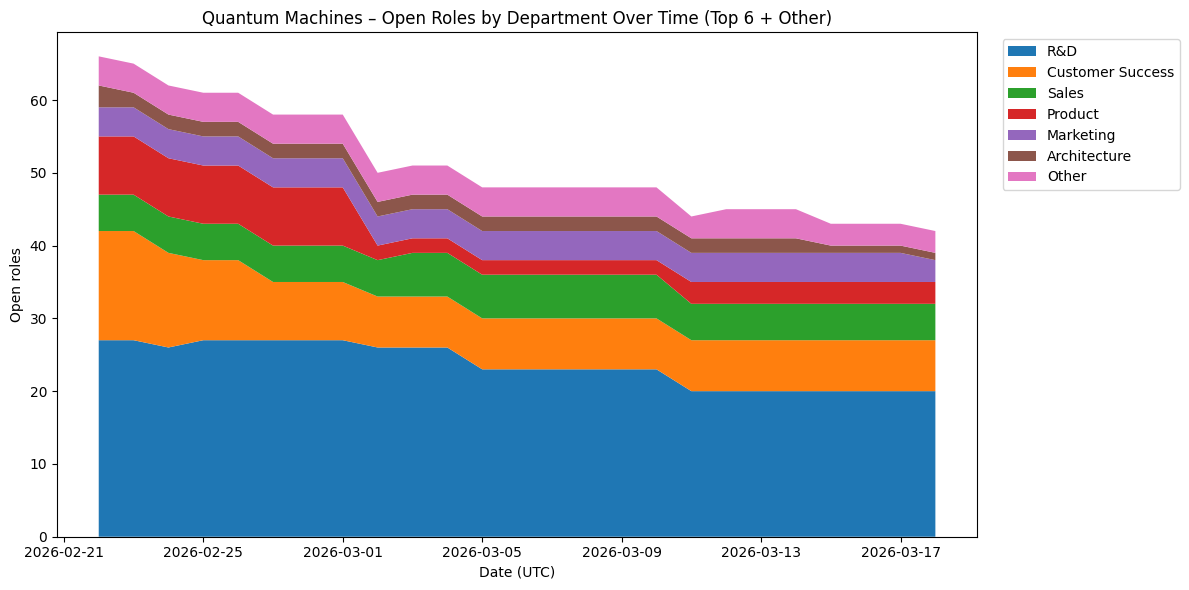

In [10]:
N = 6
avg_counts = pivot_daily.mean(axis=0).sort_values(ascending=False)
top = list(avg_counts.head(N).index)

pivot_top = pivot_daily[top].copy()
pivot_top["Other"] = pivot_daily.drop(columns=top, errors="ignore").sum(axis=1)

plt.figure(figsize=(12, 6))
plt.stackplot(pivot_top.index, pivot_top.T.values, labels=pivot_top.columns)
plt.title(f"Quantum Machines – Open Roles by Department Over Time (Top {N} + Other)")
plt.xlabel("Date (UTC)")
plt.ylabel("Open roles")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

In [11]:
ROLE_FAMILY_RULES = [
    ("Compiler / Tooling",  r"\b(compiler|tooling|sdk|language|runtime|ir)\b"),
    ("Backend / Platform",  r"\b(backend|platform|infrastructure|cloud|distributed|services|api)\b"),
    ("Hardware / EE",       r"\b(hardware|fpga|pcb|rf|analog|digital|embedded|firmware)\b"),
    ("Test / QA / Validation", r"\b(test|qa|validation|verification|reliability)\b"),
    ("Product",             r"\b(product|pm|product manager|ux|ui|design)\b"),
    ("GTM (Sales/Marketing)", r"\b(sales|account|marketing|growth|partnerships|bd|business development)\b"),
    ("G&A (Finance/HR/Ops/Legal)", r"\b(finance|bookkeeper|accounting|hr|recruit|people|operations|legal)\b"),
]

def role_family_from_title(title: str) -> str:
    if not title:
        return "Other / Unknown"
    t = title.lower()
    for label, pattern in ROLE_FAMILY_RULES:
        if re.search(pattern, t):
            return label
    return "Other / Unknown"

In [12]:
ROLE_FAMILY_RULES = [
    ("Compiler / Tooling",  r"\b(compiler|tooling|sdk|language|runtime|ir)\b"),
    ("Backend / Platform",  r"\b(backend|platform|infrastructure|cloud|distributed|services|api)\b"),
    ("Hardware / EE",       r"\b(hardware|fpga|pcb|rf|analog|digital|embedded|firmware)\b"),
    ("Test / QA / Validation", r"\b(test|qa|validation|verification|reliability)\b"),
    ("Product",             r"\b(product|pm|product manager|ux|ui|design)\b"),
    ("GTM (Sales/Marketing)", r"\b(sales|account|marketing|growth|partnerships|bd|business development)\b"),
    ("G&A (Finance/HR/Ops/Legal)", r"\b(finance|bookkeeper|accounting|hr|recruit|people|operations|legal)\b"),
]

def role_family_from_title(title: str) -> str:
    if not title:
        return "Other / Unknown"
    t = title.lower()
    for label, pattern in ROLE_FAMILY_RULES:
        if re.search(pattern, t):
            return label
    return "Other / Unknown"

In [13]:
SENIORITY_PATTERNS = [
    ("Intern",   r"\bintern\b"),
    ("Junior",   r"\b(junior|jr\.?)\b"),
    ("Mid",      r"\b(engineer|developer|analyst|scientist)\b"),  # default-ish bucket
    ("Senior",   r"\b(senior|sr\.?)\b"),
    ("Staff",    r"\bstaff\b"),
    ("Principal",r"\bprincipal\b"),
    ("Lead",     r"\blead\b"),
    ("Manager",  r"\b(manager|head of|director|vp)\b"),
]

def seniority_from_title(title: str) -> str:
    if not title:
        return "Unknown"
    t = title.lower()
    # prioritize explicit levels
    for label, pat in SENIORITY_PATTERNS:
        if re.search(pat, t):
            return label
    return "Unknown"

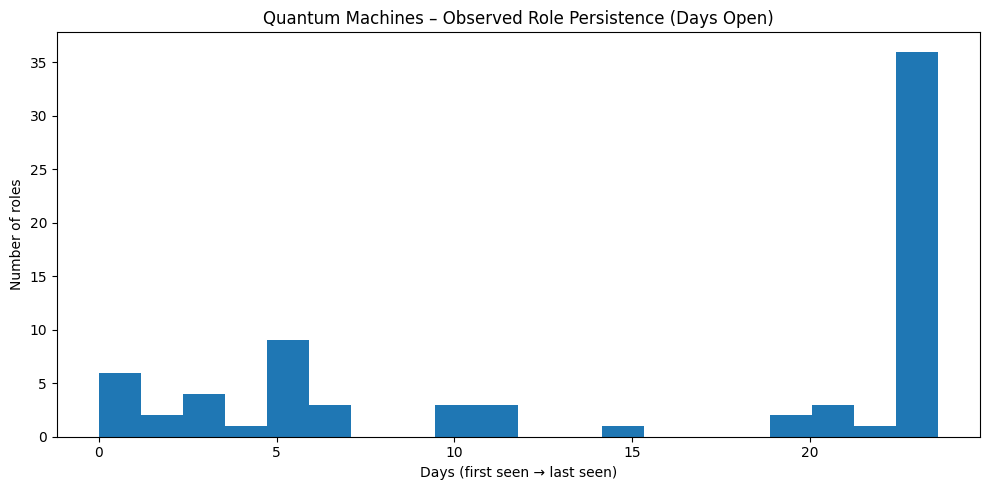

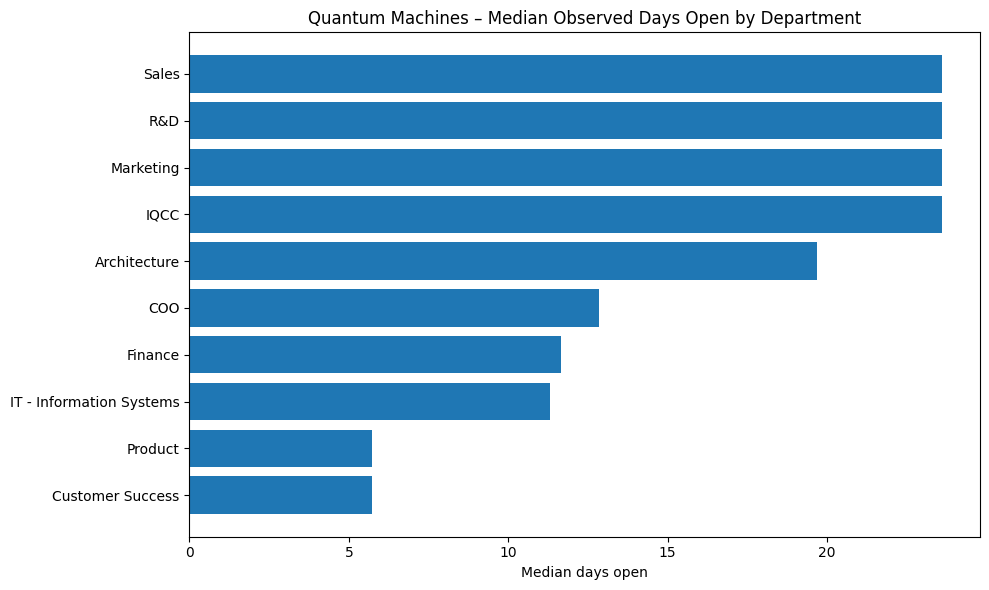

In [14]:
df_snap = run_query("""
SELECT pulled_at, job_id, title, department
FROM job_snapshots
WHERE company = 'Quantum Machines';
""")

df_snap["pulled_at"] = pd.to_datetime(df_snap["pulled_at"], utc=True)

first_last = (df_snap.groupby(["job_id", "title", "department"])["pulled_at"]
              .agg(first_seen="min", last_seen="max")
              .reset_index())

first_last["days_open_observed"] = (first_last["last_seen"] - first_last["first_seen"]).dt.total_seconds() / (3600*24)

# Distribution (overall)
plt.figure(figsize=(10, 5))
plt.hist(first_last["days_open_observed"], bins=20)
plt.title("Quantum Machines – Observed Role Persistence (Days Open)")
plt.xlabel("Days (first seen → last seen)")
plt.ylabel("Number of roles")
plt.tight_layout()
plt.show()

# Median by department (when you have enough data)
dept_persist = (first_last.groupby("department")["days_open_observed"]
                .median()
                .reset_index(name="median_days_open")
                .sort_values("median_days_open"))

plt.figure(figsize=(10, 6))
plt.barh(dept_persist["department"], dept_persist["median_days_open"])
plt.title("Quantum Machines – Median Observed Days Open by Department")
plt.xlabel("Median days open")
plt.tight_layout()
plt.show()

In [15]:
import re
import pandas as pd

# Pull current roles (self-contained)
df_roles = run_query("""
SELECT title, department, location, modality
FROM job_current
WHERE company = 'Quantum Machines';
""")

def split_location(loc: str):
    if not loc or str(loc).strip().lower() in ("none", "nan"):
        return ("(Unknown)", "(Unknown)")
    s = " ".join(str(loc).split()).strip()
    parts = s.split(" ")
    if len(parts) == 1:
        return (parts[0], "(Unknown)")
    return (" ".join(parts[:-1]), parts[-1])

# Build geo from scratch so we never depend on previous notebook state
geo = df_roles.copy()
geo["modality"] = geo["modality"].fillna("(Unknown)")

# Create city/country columns (this is what you were missing)
geo[["city", "country"]] = geo["location"].apply(lambda x: pd.Series(split_location(x)))

COUNTRY_TO_REGION = {
    "Israel": "Israel",
    "Germany": "Europe",
    "Netherlands": "Europe",
    "UK": "Europe",
    "United Kingdom": "Europe",
    "France": "Europe",
    "Sweden": "Europe",
    "Switzerland": "Europe",
    "Italy": "Europe",
    "Spain": "Europe",
    "Ireland": "Europe",
    "Denmark": "Europe",
    "Norway": "Europe",
    "Finland": "Europe",
    "Austria": "Europe",
    "Belgium": "Europe",
    "Poland": "Europe",
    "Portugal": "Europe",
    "Greece": "Europe",
    "USA": "North America",
    "US": "North America",
    "United States": "North America",
    "Canada": "North America",
    "Singapore": "South East Asia",
    "Japan": "East Asia",
    "South Korea": "East Asia",
}

def region_from_country_and_modality(country: str, modality: str) -> str:
    # Keep Remote separate so it doesn't muddy geography
    if isinstance(modality, str) and modality.strip().lower() == "remote":
        return "Remote"
    c = str(country).strip() if country else "(Unknown)"
    return COUNTRY_TO_REGION.get(c, "Other / Unknown")

geo["region"] = geo.apply(lambda r: region_from_country_and_modality(r["country"], r["modality"]), axis=1)

ROLE_FAMILY_RULES = [
    ("Compiler / Tooling",  r"\b(compiler|tooling|sdk|language|runtime|ir)\b"),
    ("Backend / Platform",  r"\b(backend|platform|infrastructure|cloud|distributed|services|api)\b"),
    ("G&A (Finance/HR/Ops/Legal)", r"\b(finance|bookkeeper|accounting|hr|recruit|people|operations|legal)\b"),
]

def role_family_from_title(title: str) -> str:
    if not title:
        return "Other / Unknown"
    t = str(title).lower()
    for label, pattern in ROLE_FAMILY_RULES:
        if re.search(pattern, t):
            return label
    return "Other / Unknown"

geo["role_family"] = geo["title"].apply(role_family_from_title)

print("Columns:", geo.columns.tolist())
print(geo[["location","country","modality","region","role_family"]].head())
print("\nRegion counts:\n", geo["region"].value_counts())

Columns: ['title', 'department', 'location', 'modality', 'city', 'country', 'region', 'role_family']
            location      country modality  region                 role_family
0    Tel Aviv Israel       Israel   Hybrid  Israel          Backend / Platform
1    Tel Aviv Israel       Israel  On-site  Israel  G&A (Finance/HR/Ops/Legal)
2    Tel Aviv Israel       Israel   Hybrid  Israel          Compiler / Tooling
3  Stuttgart Germany      Germany   Remote  Remote          Compiler / Tooling
4  Delft Netherlands  Netherlands   Remote  Remote          Compiler / Tooling

Region counts:
 region
Israel           30
Remote           24
Europe           16
North America     3
Name: count, dtype: int64


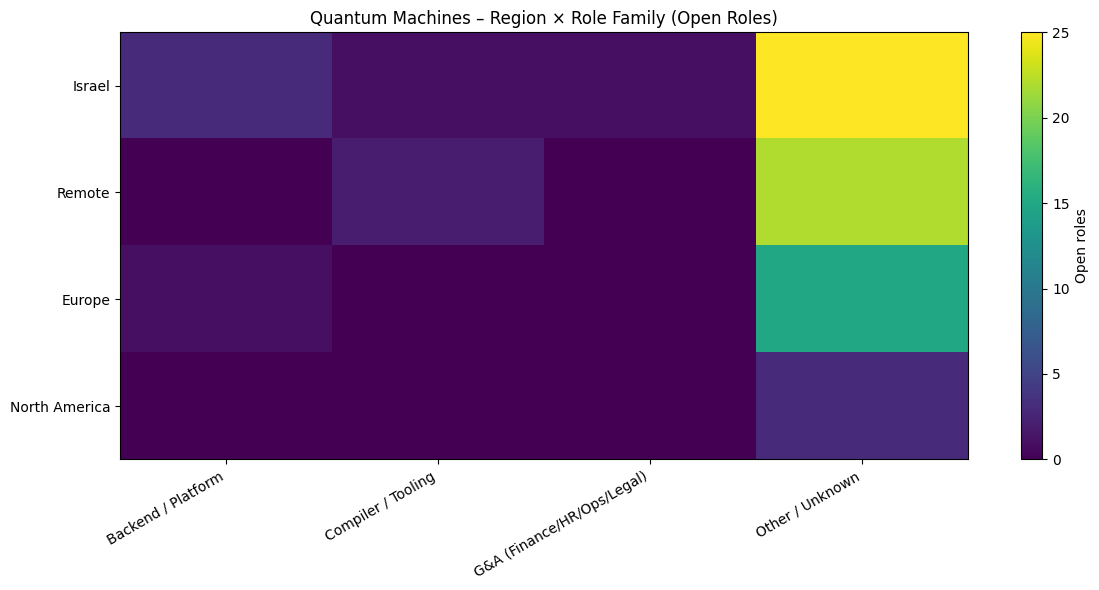

In [16]:
rf = (geo.groupby(["region", "role_family"]).size().reset_index(name="n"))
pivot_rf = rf.pivot_table(index="region", columns="role_family", values="n", fill_value=0)
pivot_rf = pivot_rf.loc[pivot_rf.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(12, 6))
plt.imshow(pivot_rf.values, aspect="auto")
plt.xticks(range(pivot_rf.shape[1]), pivot_rf.columns, rotation=30, ha="right")
plt.yticks(range(pivot_rf.shape[0]), pivot_rf.index)
plt.title("Quantum Machines – Region × Role Family (Open Roles)")
plt.colorbar(label="Open roles")
plt.tight_layout()
plt.show()

In [17]:
def split_location(loc: str):
    if not loc or loc.strip().lower() in ("none", "nan"):
        return ("(Unknown)", "(Unknown)")
    s = " ".join(loc.split()).strip()
    parts = s.split(" ")
    # Heuristic: last token is country, rest is city (works for your current samples)
    if len(parts) == 1:
        return (parts[0], "(Unknown)")
    return (" ".join(parts[:-1]), parts[-1])

geo = df_roles.copy()
geo[["city", "country"]] = geo["location"].apply(lambda x: pd.Series(split_location(x)))
geo["modality"] = geo["modality"].fillna("(Unknown)")

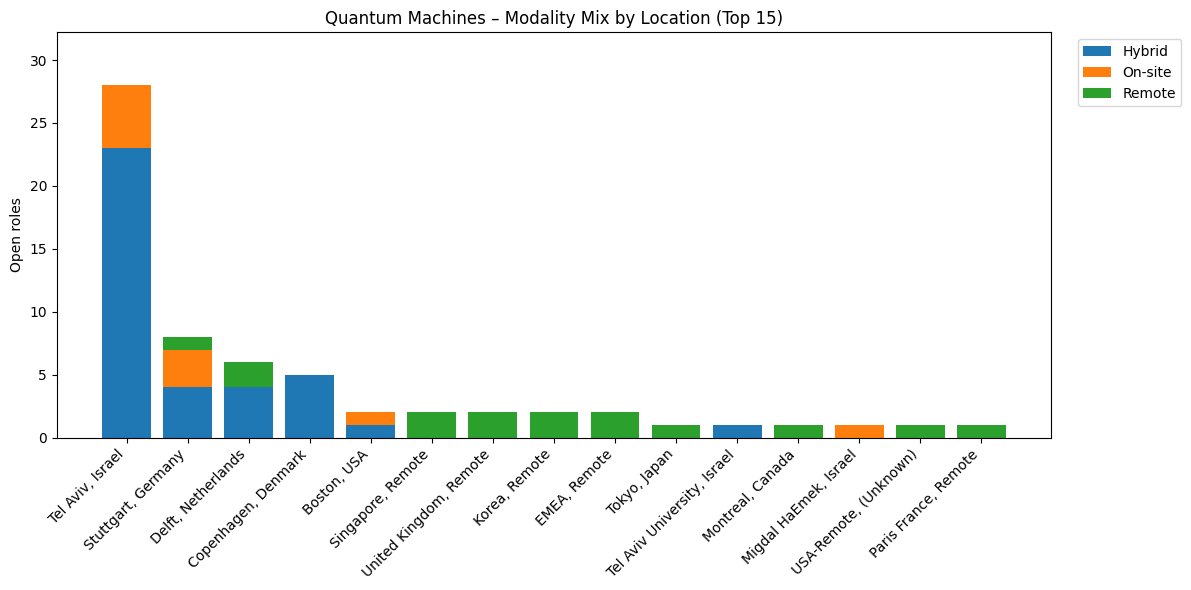

In [18]:
geo_mod = (geo.groupby(["country", "city", "modality"])
           .size()
           .reset_index(name="n"))

pivot_geo_mod = (geo_mod.pivot_table(index=["country","city"], columns="modality", values="n", fill_value=0))
pivot_geo_mod["total"] = pivot_geo_mod.sum(axis=1)
pivot_geo_mod = pivot_geo_mod.sort_values("total", ascending=False).head(15)
pivot_geo_mod = pivot_geo_mod.drop(columns=["total"])

plt.figure(figsize=(12, 6))
bottom = None
for col in pivot_geo_mod.columns:
    if bottom is None:
        plt.bar(range(len(pivot_geo_mod)), pivot_geo_mod[col], label=col)
        bottom = pivot_geo_mod[col].values
    else:
        plt.bar(range(len(pivot_geo_mod)), pivot_geo_mod[col], bottom=bottom, label=col)
        bottom = bottom + pivot_geo_mod[col].values

# ---- HEADROOM ----
# At this point, "bottom" contains the final stacked bar heights for each location.
max_height = bottom.max()
plt.ylim(0, max_height * 1.15)

labels = [f"{idx[1]}, {idx[0]}" for idx in pivot_geo_mod.index]  # "City, Country"
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.title("Quantum Machines – Modality Mix by Location (Top 15)")
plt.ylabel("Open roles")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

In [19]:
df_changes = run_query("""
SELECT pulled_at, change_type, COUNT(*) as n
FROM job_changes
WHERE company = 'Quantum Machines'
GROUP BY pulled_at, change_type
ORDER BY pulled_at;
""")

df_changes

,pulled_at,change_type,n
0,2026-02-22T21:41:09+00:00,added,66
1,2026-02-22T23:05:55+00:00,no_change,1
2,2026-02-22T23:21:14+00:00,no_change,1
3,2026-02-22T23:21:25+00:00,no_change,1
4,2026-02-22T23:26:33+00:00,no_change,1
5,2026-02-23T13:59:44+00:00,removed,2
6,2026-02-23T14:01:22+00:00,no_change,1
7,2026-02-23T15:33:05+00:00,no_change,1
8,2026-02-23T18:27:20+00:00,no_change,1
9,2026-02-24T18:59:19+00:00,changed,2


In [20]:
df_titles = run_query("""
SELECT title
FROM job_current
WHERE company = 'Quantum Machines' AND title IS NOT NULL;
""")

titles = df_titles["title"].astype(str).tolist()

In [21]:
import re
from collections import Counter

# keep engineer etc.
STOPWORDS = {
    "and","or","the","a","an","of","to","for","in","on","with","at","by","from",
    "ii","iii","iv","jr","sr"
}

def tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s\-+]", " ", text)
    tokens = re.split(r"\s+", text.strip())
    tokens = [t for t in tokens if t and t not in STOPWORDS]
    return tokens

all_bigrams = []

for t in titles:
    toks = tokenize(t)
    all_bigrams.extend([" ".join(pair) for pair in zip(toks, toks[1:])])

bigram_counts = Counter(all_bigrams)

# require at least 2 occurrences
min_freq = 2
filtered = {k:v for k,v in bigram_counts.items() if v >= min_freq}

top_bigrams = sorted(filtered.items(), key=lambda x: x[1], reverse=True)[:15]

df_bigrams = pd.DataFrame(top_bigrams, columns=["bigram","count"])
df_bigrams.sort_values("count", ascending=True)

,bigram,count
14,backend engineer,2
10,compiler engineer,3
11,marketing programs,3
12,programs manager,3
13,verification engineer,3
6,physics solution,5
9,science communication,5
7,solution marketing,5
8,marketing science,5
3,scientific business,6


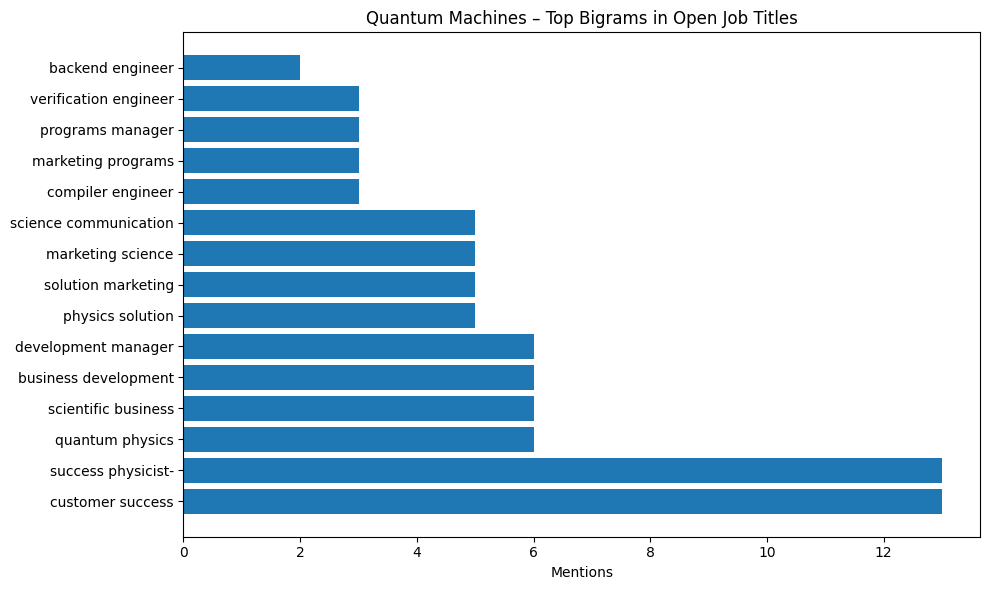

In [22]:
plt.figure(figsize=(10,6))
plt.barh(df_bigrams["bigram"], df_bigrams["count"])
plt.title("Quantum Machines – Top Bigrams in Open Job Titles")
plt.xlabel("Mentions")
plt.tight_layout()
plt.show()

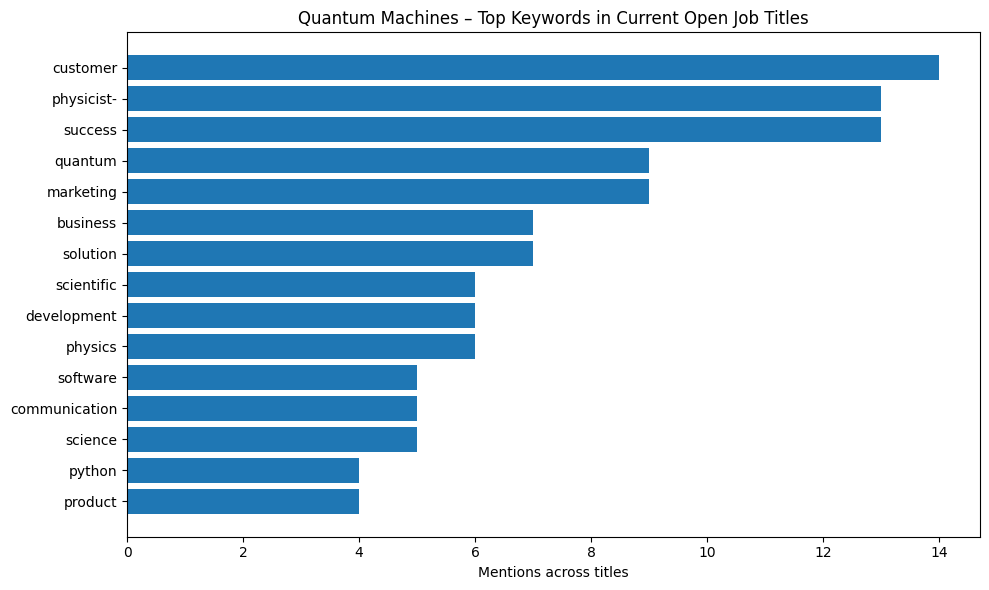

,keyword,count
0,customer,14
1,success,13
2,physicist-,13
3,marketing,9
4,quantum,9
5,solution,7
6,business,7
9,development,6
7,physics,6
8,scientific,6


In [23]:
import re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# Pull current titles
df_titles = run_query("""
SELECT title
FROM job_current
WHERE company = 'Quantum Machines' AND title IS NOT NULL;
""")

titles = df_titles["title"].astype(str).tolist()

# Basic stopwords + job-generic words (tune as you like)
STOPWORDS = {
    "and","or","the","a","an","of","to","for","in","on","with","at","by","from",
    "ii","iii","iv","jr","sr"
}
JOB_GENERIC = {
    "engineer","engineering","developer","developer","manager","lead","senior",
    "staff","principal","intern","associate","specialist","director","head"
}

# Tokenizer
def tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s\-+]", " ", text)   # keep letters/numbers and -/+
    tokens = re.split(r"\s+", text.strip())
    tokens = [t for t in tokens if t and t not in STOPWORDS and t not in JOB_GENERIC]
    # drop short tokens like "qa" maybe keep; adjust as needed:
    tokens = [t for t in tokens if len(t) >= 2]
    return tokens

all_tokens = []
for t in titles:
    all_tokens.extend(tokenize(t))

counts = Counter(all_tokens)
top_n = 15
top = counts.most_common(top_n)

df_kw = pd.DataFrame(top, columns=["keyword","count"]).sort_values("count")

plt.figure(figsize=(10, 6))
plt.barh(df_kw["keyword"], df_kw["count"])
plt.title("Quantum Machines – Top Keywords in Current Open Job Titles")
plt.xlabel("Mentions across titles")
plt.tight_layout()
plt.show()

df_kw.sort_values("count", ascending=False)

In [24]:
## Hiring Signal Interpretation

#- Heavy R&D weighting suggests...
#- Compiler roles indicate...
#- Finance hire suggests...
#- Remote EU roles suggest...